## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv("D:/uni/term 6/data analytics/project/dataset_merged/dataset_merged/train.csv")

In [4]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [8]:
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


## Missing Values

In [6]:
missingValues = df.isnull().sum()
missingValues

id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_

# Numerical EDA

## 1) Skewness And Kurtosis

In [7]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()

skewness_values = df[numerical_cols].skew()
print("=== SKEWNESS ===\n", skewness_values)

kurtosis_values = df[numerical_cols].kurtosis()
print("\n=== KURTOSIS ===\n", kurtosis_values)

=== SKEWNESS ===
 id                    0.002623
amount_tsh           57.807800
gps_height            0.462402
longitude            -4.191046
latitude             -0.152037
num_private          91.933750
region_code           3.173818
district_code         3.962045
population           12.660714
construction_year    -0.634928
dtype: float64

=== KURTOSIS ===
 id                      -1.201515
amount_tsh            4903.543102
gps_height              -1.292440
longitude               19.187031
latitude                -1.057617
num_private          11137.295213
region_code             10.288433
district_code           16.214284
population             402.280115
construction_year       -1.596432
dtype: float64


## 2) KDE

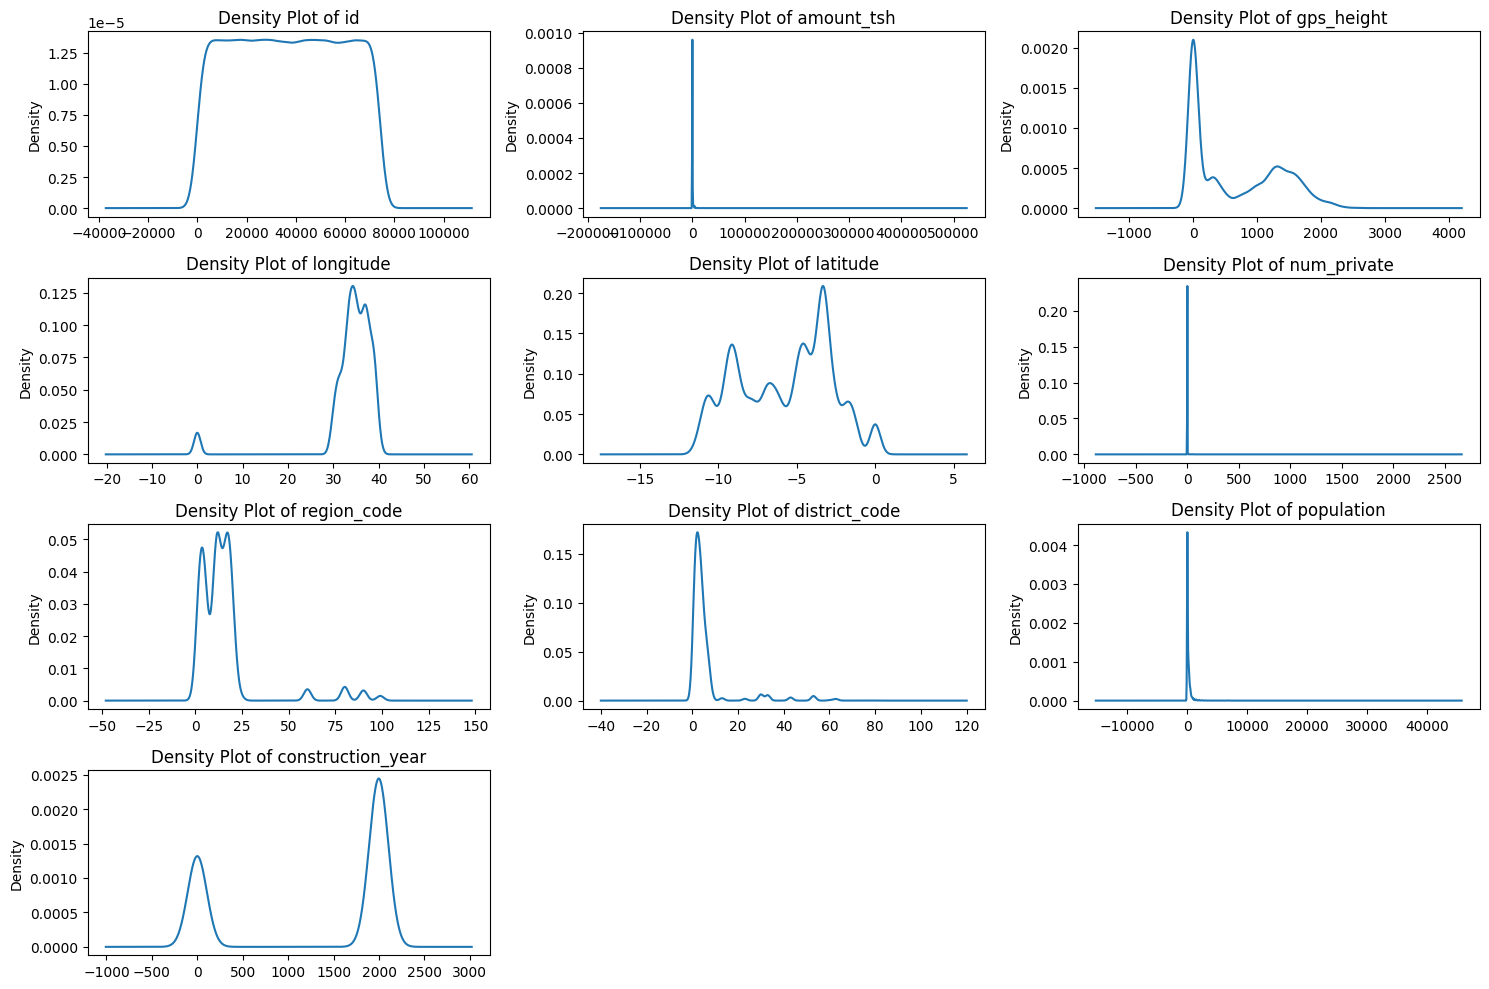

In [9]:
numerical_df = df.select_dtypes(include="number")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_df.columns.tolist()):
    plt.subplot(4, 3, i+1)
    numerical_df[col].plot(kind='kde')
    plt.title(f'Density Plot of {col}')
plt.tight_layout()
plt.show()

## 3) Boxplots

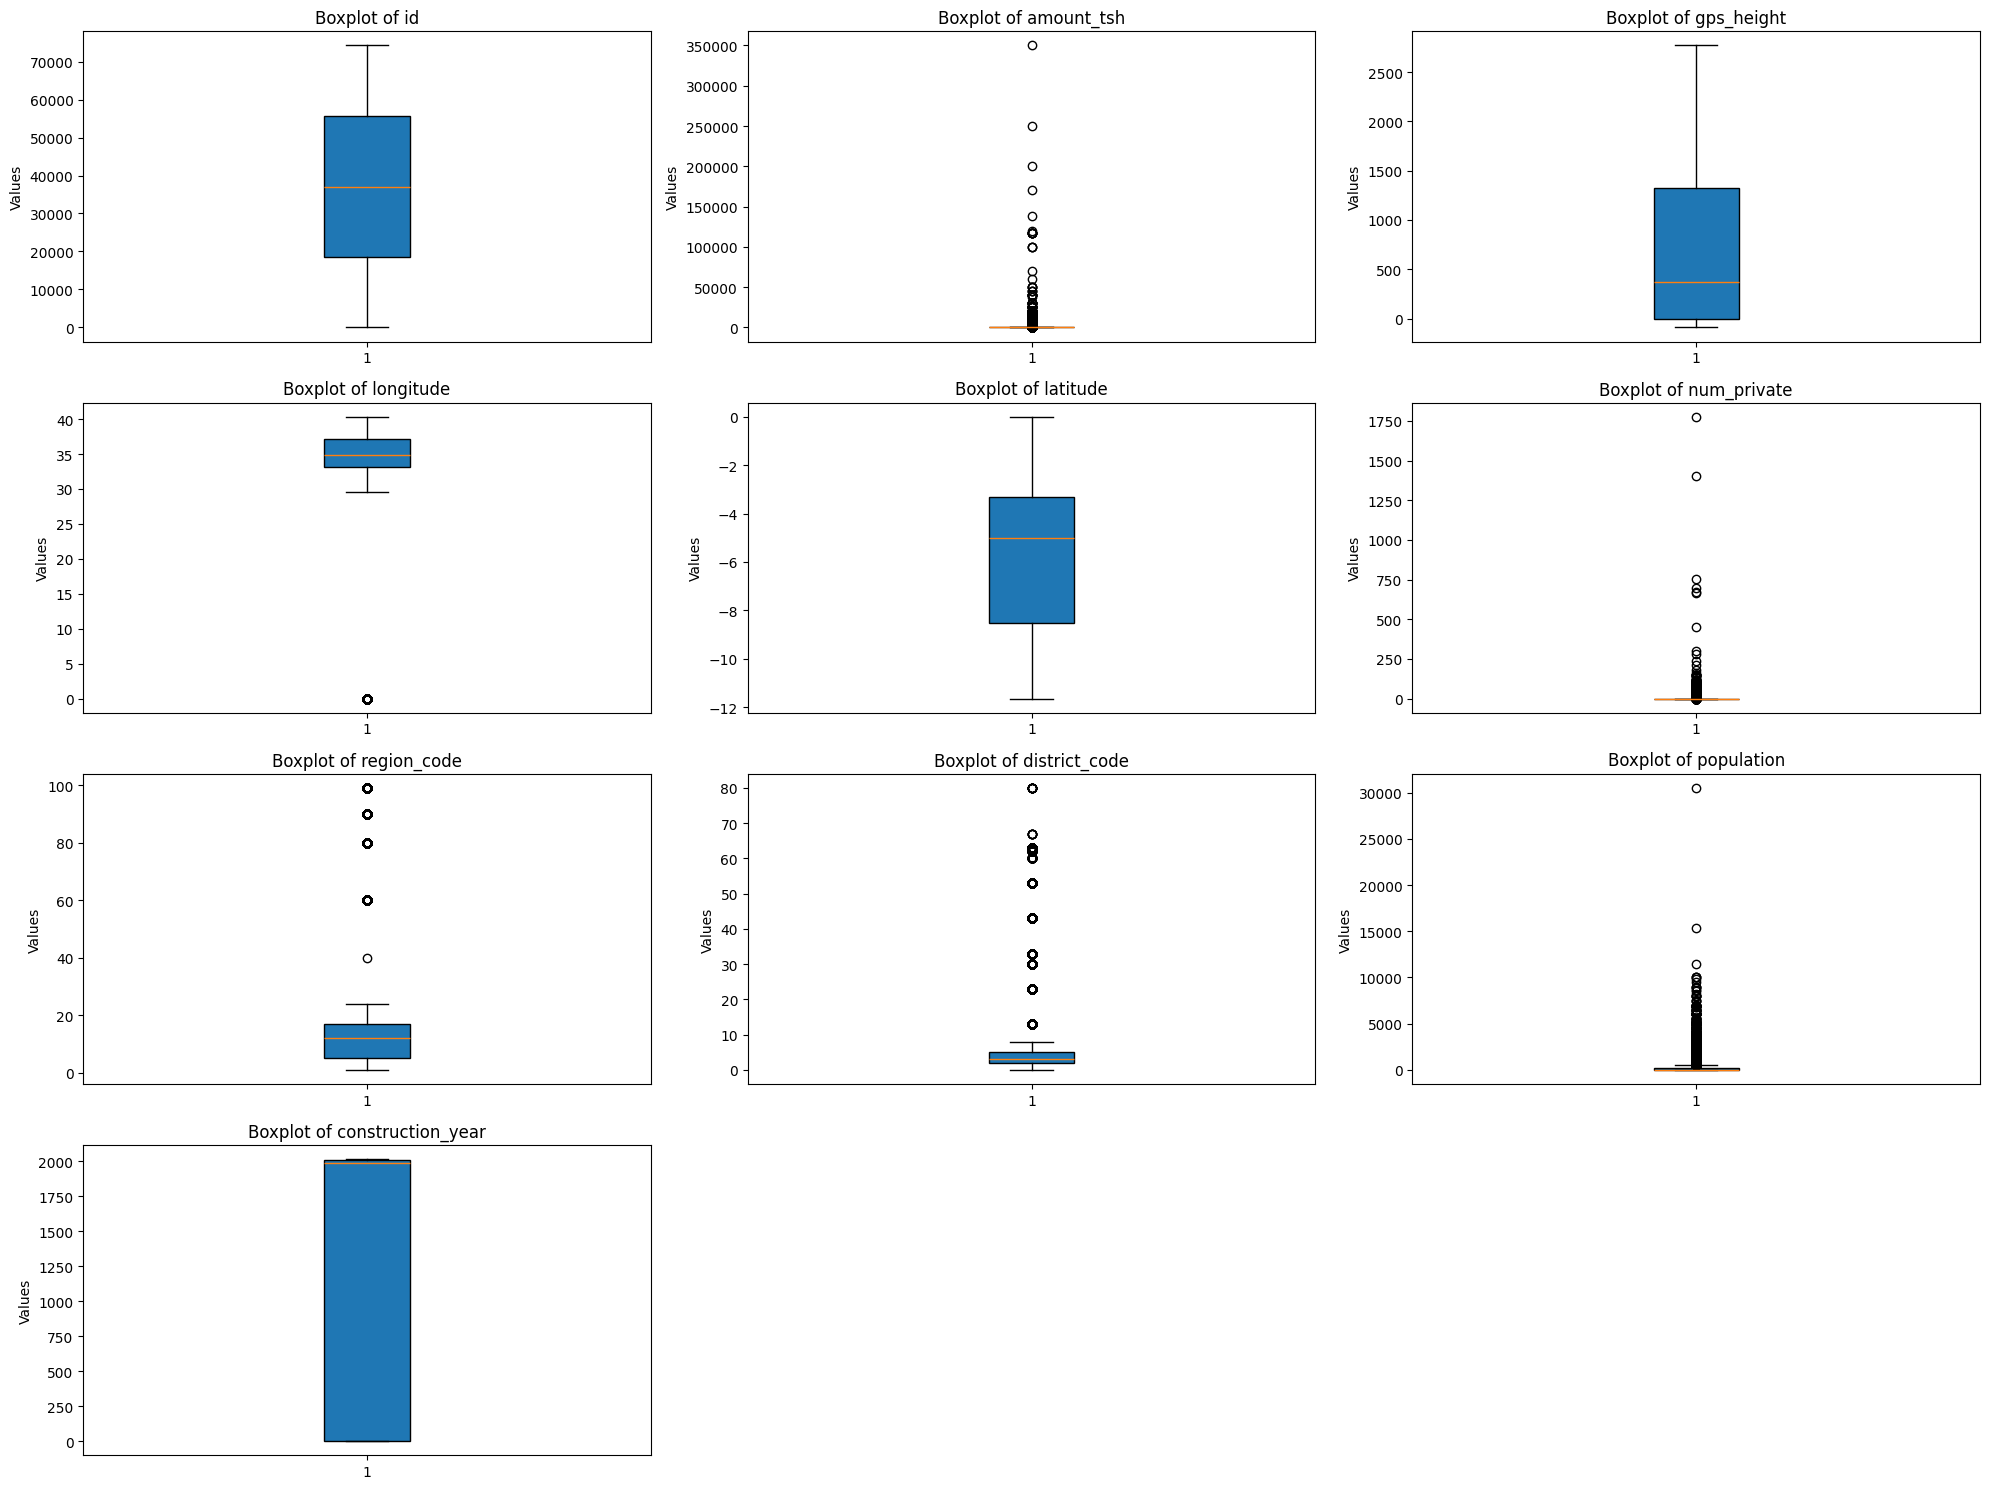

In [12]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_df.columns, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')
plt.tight_layout()
plt.show()

## 4) Correlation Matrix And Heatmap

=== CORRELATION MATRIX ===
                         id  amount_tsh  gps_height  longitude  latitude  \
id                 1.000000   -0.005321   -0.004692  -0.001348  0.001718   
amount_tsh        -0.005321    1.000000    0.076650   0.022134 -0.052670   
gps_height        -0.004692    0.076650    1.000000   0.149155 -0.035751   
longitude         -0.001348    0.022134    0.149155   1.000000 -0.425802   
latitude           0.001718   -0.052670   -0.035751  -0.425802  1.000000   
num_private       -0.002629    0.002944    0.007237   0.023873  0.006837   
region_code       -0.003028   -0.026813   -0.183521   0.034197 -0.221018   
district_code     -0.003044   -0.023599   -0.171233   0.151398 -0.201020   
population        -0.002813    0.016288    0.135003   0.086590 -0.022152   
construction_year -0.002082    0.067915    0.658727   0.396732 -0.245278   

                   num_private  region_code  district_code  population  \
id                   -0.002629    -0.003028      -0.003044   -

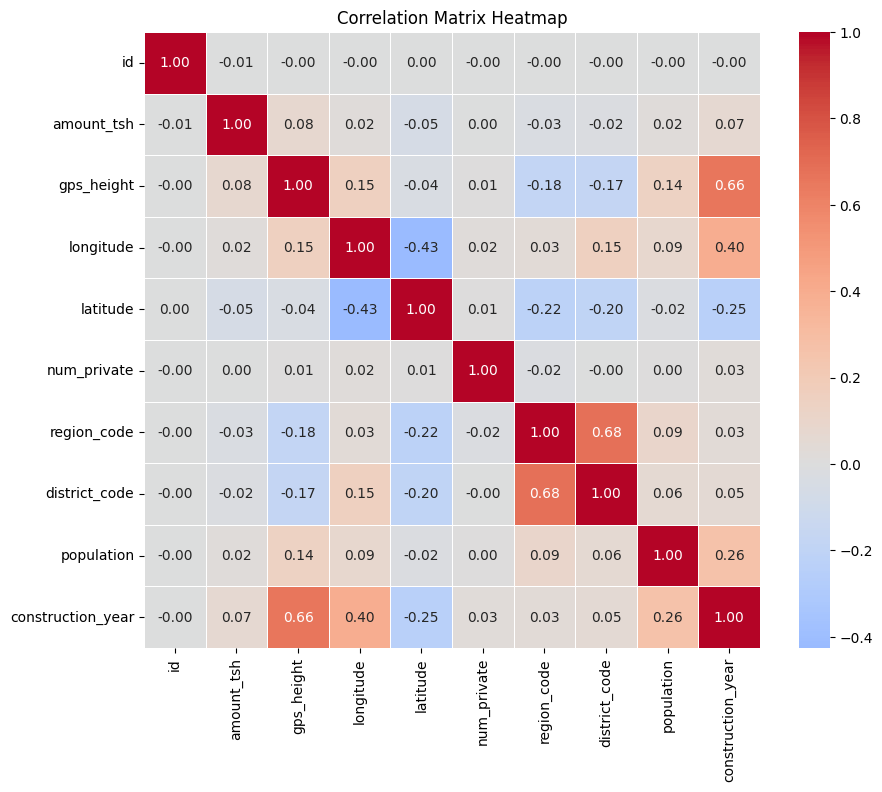

In [13]:
corr_matrix = numerical_df.corr()
print("=== CORRELATION MATRIX ===")
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## 5) Scatterplots

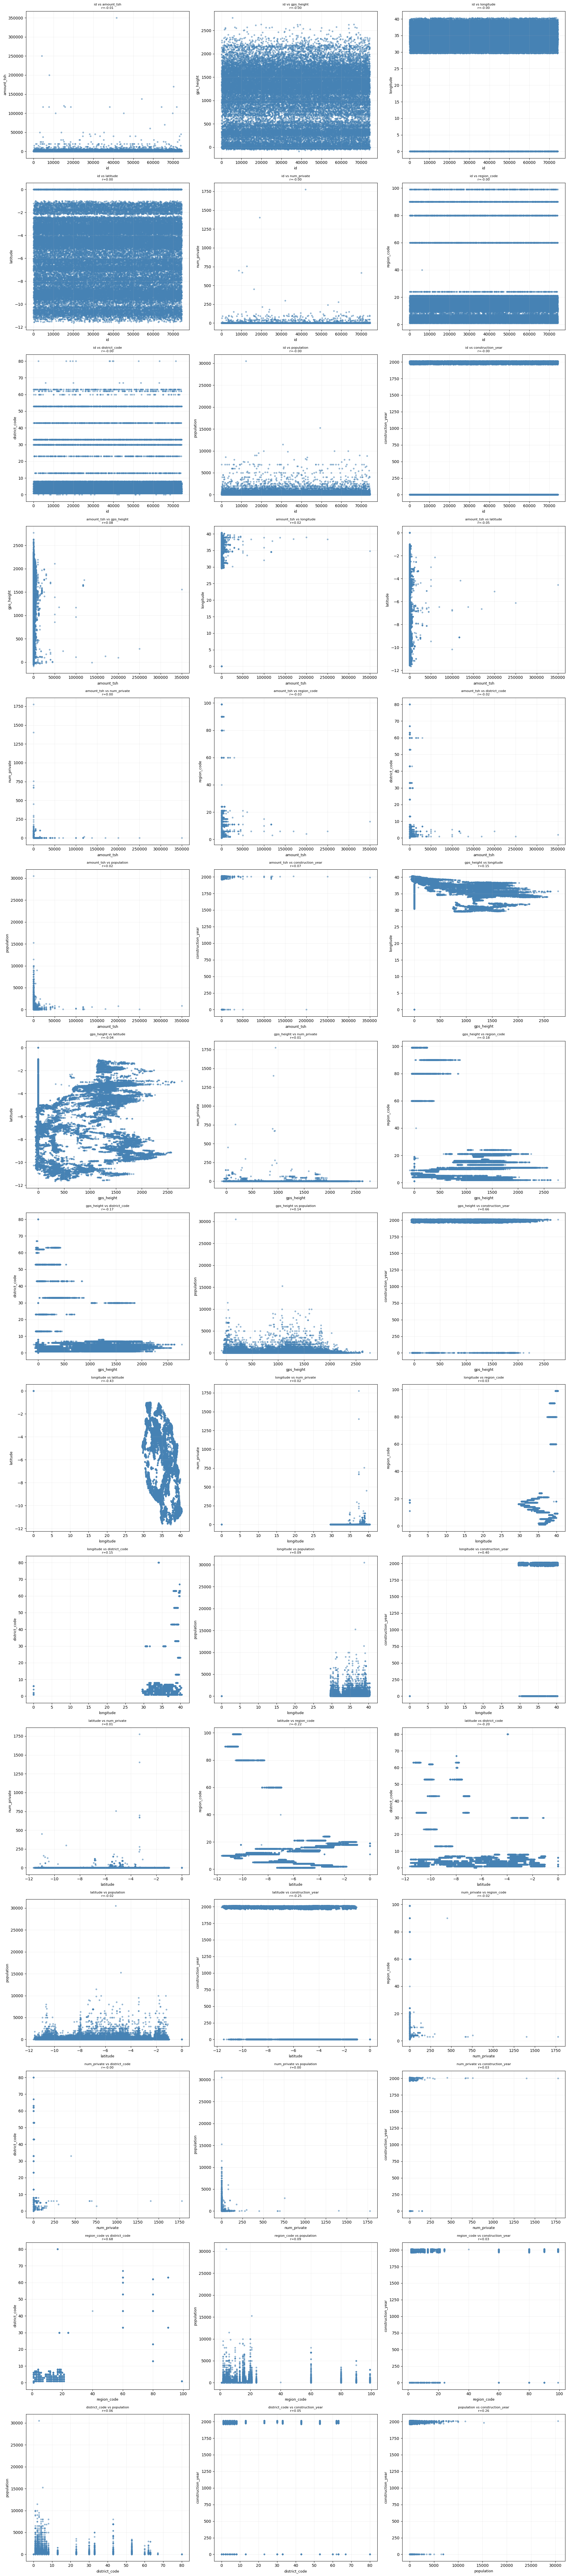

In [18]:
import math

n_cols = len(numerical_cols)
n_pairs = (n_cols * (n_cols - 1)) // 2
n_rows = math.ceil(n_pairs / 3) 

plt.figure(figsize=(20, 6 * n_rows))
plot_num = 1

for i in range(n_cols):
    for j in range(i+1, n_cols):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        
        plt.subplot(n_rows, 3, plot_num)
        plt.scatter(df[col1], df[col2], alpha=0.5, color='steelblue', s=10)
        plt.xlabel(col1, fontsize=9)
        plt.ylabel(col2, fontsize=9)
        
        corr_val = numerical_df[col1].corr(numerical_df[col2])
        plt.title(f'{col1} vs {col2}\nr={corr_val:.2f}', fontsize=8)
        plt.grid(alpha=0.3, linewidth=0.5)
        
        plot_num += 1

plt.tight_layout()
plt.show()

## 6) Histogram

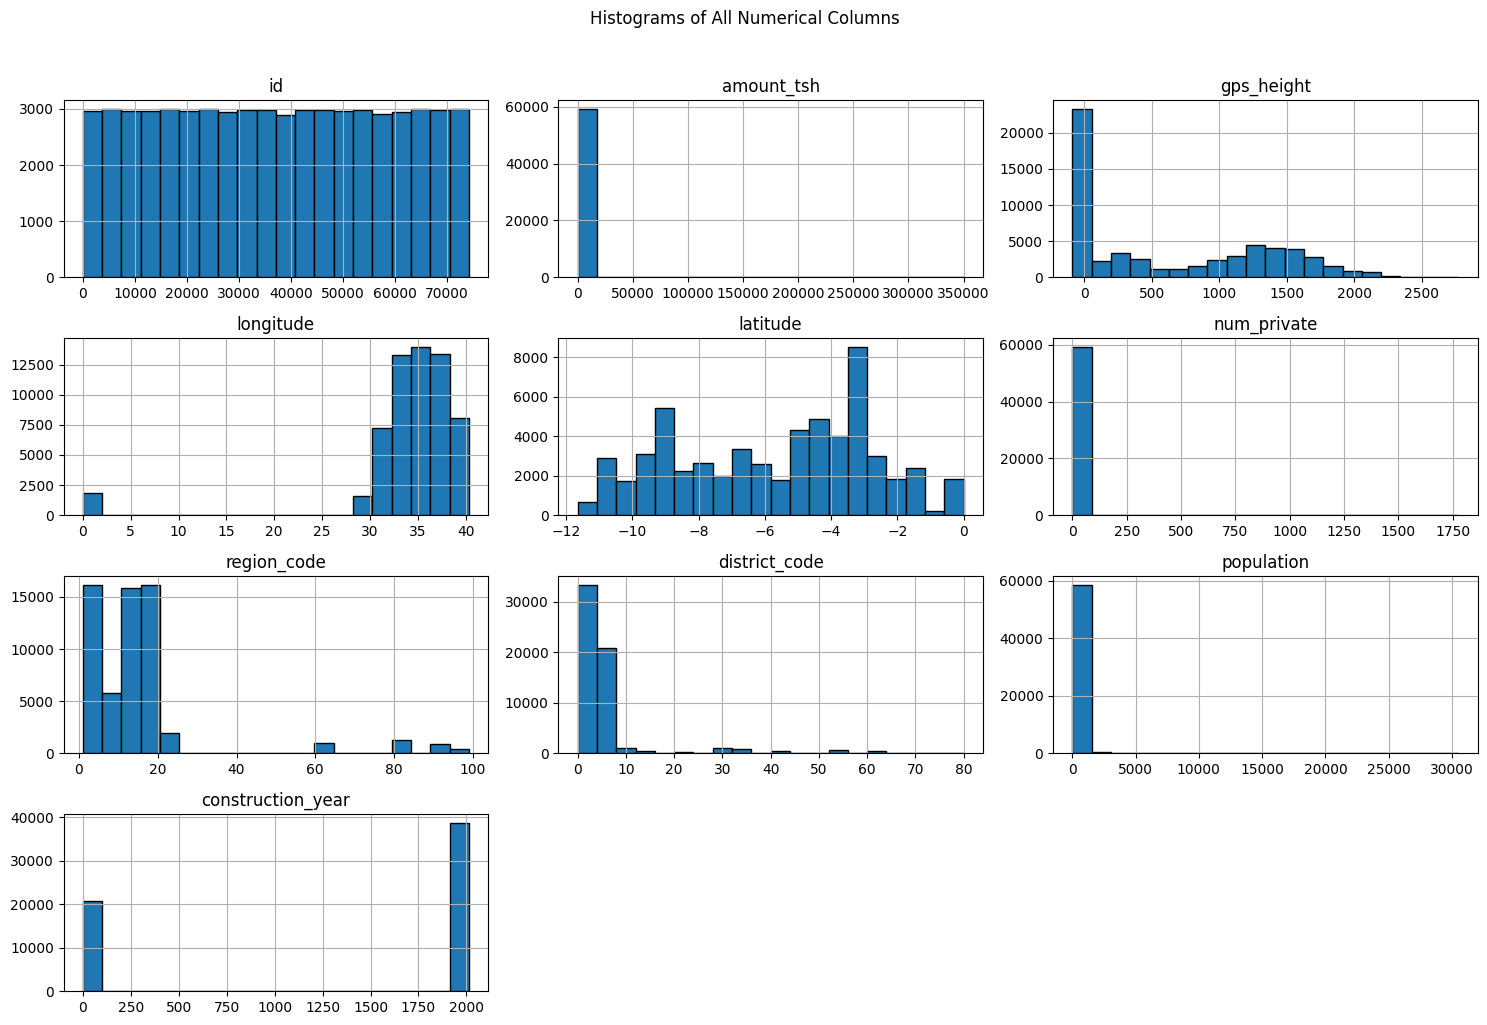

In [19]:
numerical_df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Histograms of All Numerical Columns', y=1.02)
plt.tight_layout()
plt.show()

# Categorical EDA

## Non-Graphical Univariate

In [21]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    
    # Frequency tabulation
    freq = df[col].value_counts()
    print("\n Frequency:")
    print(freq)
    
    # Percentages
    prop = df[col].value_counts(normalize=True) * 100
    print("\n Proportions (%):")
    print(prop.round(2))
    
    # Most common category
    mode_val = df[col].mode()[0]
    mode_pct = (df[col] == mode_val).mean() * 100
    print(f"\n Most common: '{mode_val}' ({mode_pct:.1f}% of data)")
    
    # Unique categories count
    print(f" Unique categories: {df[col].nunique()}")


Column: date_recorded

 Frequency:
date_recorded
2011-03-15    572
2011-03-17    558
2013-02-03    546
2011-03-14    520
2011-03-16    513
             ... 
2011-09-25      1
2004-04-01      1
2011-09-26      1
2011-09-12      1
2013-12-01      1
Name: count, Length: 356, dtype: int64

 Proportions (%):
date_recorded
2011-03-15    0.96
2011-03-17    0.94
2013-02-03    0.92
2011-03-14    0.88
2011-03-16    0.86
              ... 
2011-09-25    0.00
2004-04-01    0.00
2011-09-26    0.00
2011-09-12    0.00
2013-12-01    0.00
Name: proportion, Length: 356, dtype: float64

 Most common: '2011-03-15' (1.0% of data)
 Unique categories: 356

Column: funder

 Frequency:
funder
Government Of Tanzania    9084
Danida                    3114
Hesawa                    2202
Rwssp                     1374
World Bank                1349
                          ... 
Cida                         1
Dwe/anglican Church          1
Dina                         1
Brown                        1
Samlo       

## Bar Charts (For Columns With A Reasonable Number Of Unique Values)

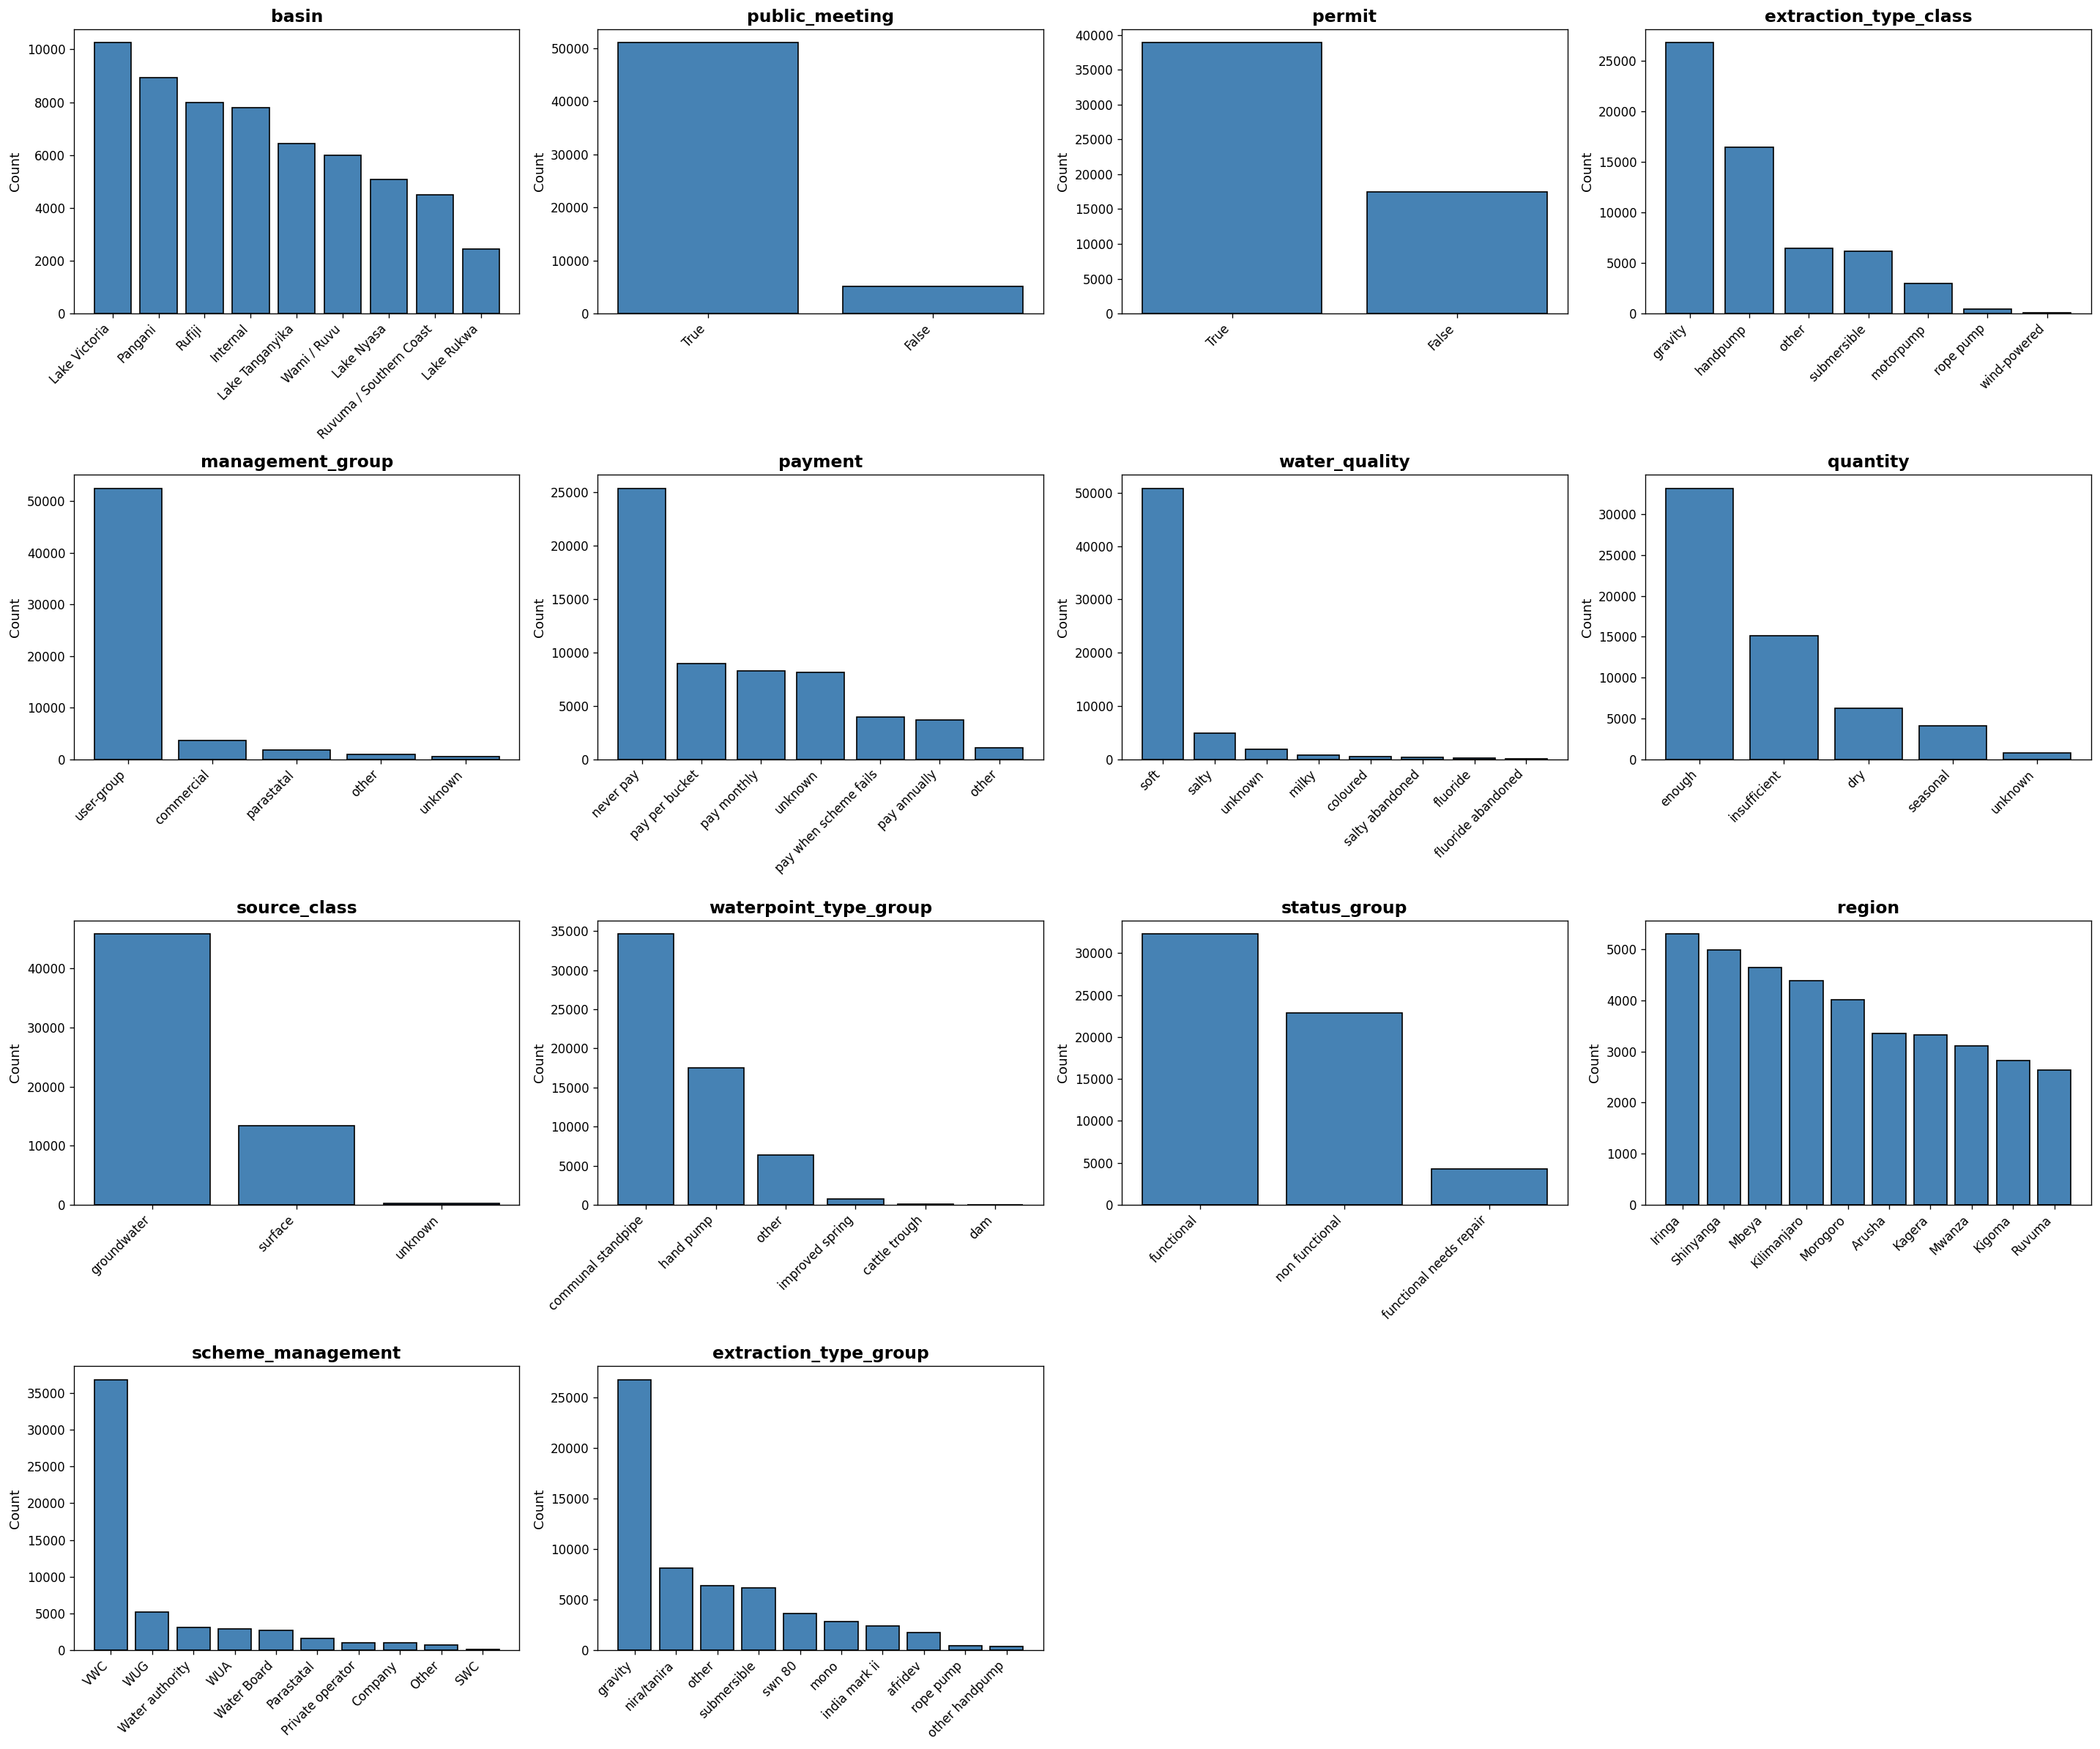

In [29]:
plot_these = [
    'basin', 'public_meeting', 'permit', 
    'extraction_type_class', 'management_group', 
    'payment', 'water_quality', 'quantity', 
    'source_class', 'waterpoint_type_group', 'status_group',
    'region', 'scheme_management', 'extraction_type_group'
]

counts_dict = {}
for col in plot_these:
    counts_dict[col] = df[col].value_counts().head(10)

n_cols = len(plot_these) 
n_rows = 4
n_cols_per_row = 4

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(24, 20))
axes = axes.flatten()

for i, col in enumerate(plot_these):
    counts = counts_dict[col]
    axes[i].bar(range(len(counts)), counts.values, color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=14, fontweight='bold')  
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=10) 
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].tick_params(axis='y', labelsize=10)  

for j in range(len(plot_these), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Cross-Tabulation (Comparing The Reasonable Columns With The Target Column)

In [32]:
predictors = [
    'basin', 'public_meeting', 'permit', 
    'extraction_type_class', 'management_group', 
    'payment', 'water_quality', 'quantity', 
    'source_class', 'waterpoint_type_group', 
    'region', 'scheme_management', 'extraction_type_group'
]   # Removed status_group, as it's the target

for col in predictors:
    print(f"\n{'='*60}")
    print(f"STATUS GROUP vs {col.upper()}")
    print(f"{'='*60}")
    cross = pd.crosstab(df['status_group'], df[col], normalize='columns').mul(100).round(1)
    print(cross)
    print("\n")


STATUS GROUP vs BASIN
basin                    Internal  Lake Nyasa  Lake Rukwa  Lake Tanganyika  \
status_group                                                                 
functional                   57.6        65.4        40.7             48.3   
functional needs repair       7.2         4.9        11.0             11.5   
non functional               35.3        29.7        48.2             40.2   

basin                    Lake Victoria  Pangani  Rufiji  \
status_group                                              
functional                        49.8     60.1    63.5   
functional needs repair            9.7      5.3     5.5   
non functional                    40.6     34.6    31.0   

basin                    Ruvuma / Southern Coast  Wami / Ruvu  
status_group                                                   
functional                                  37.2         52.4  
functional needs repair                      7.3          4.5  
non functional                    

# Conclusions

#### ***Columns To Drop***
The `recorded_by` column has only one unique value ("GeoData Consultants Ltd") across all 59,400 records, making it useless for analysis. The `scheme_name` column has 48.5% missing values and 2,695 unique values, making it impractical for modeling. Location columns with too many unique values like `wpt_name` (37,399 unique values), `subvillage` (19,287 unique values), and `ward` (2,092 unique values) should also be dropped. The `date_recorded` column also contains 356 unique values and has no causal relationship with pump status, so it can be removed.

#### ***Redundant Columns***
Several columns are duplicates or simplified versions of other columns. For each pair, we can keep the more detailed or more interpretable version and drop the other. I.e: keep `quantity` and drop `quantity_group`; keep `payment` and drop `payment_type`; keep `water_quality` and drop `quality_group`; keep `extraction_type_class` and drop `extraction_type_group`; keep `waterpoint_type` and drop `waterpoint_type_group`; keep `management_group` and drop `management`; and keep `region` while dropping `region_code` and `district_code`.

#### ***Columns Requiring Transformation***
The `amount_tsh` column has a skewness of 57.8 with 50% of values being zero. The `num_private` column has a skewness of 91.9 with almost all values being zero and a few extreme outliers. The `population` column has a skewness of 12.7 with outliers reaching 30500 while the median is only 25. The `construction_year` column has 25% of values coded as zero representing missing data; these zeros can be replaced with the median value of 1986. The `gps_height` column contains impossible negative values (minimum -90) that can be replaced with the median.

#### ***Strongest Predictors To Keep***
The `quantity` column is the strongest predictor, as 96.9% of "dry" water points are non-functional. The `payment` column shows that wells with annual payment are 75.2% functional while never-pay wells are only 44.9% functional. The `water_quality` column reveals that 84.1% of wells with "unknown" water quality are non-functional. The `extraction_type_class` column shows that 80.8% of "other" pump types are non-functional. The `region` column displays massive variation from Iringa at 78.2% functional to Lindi at only 29.8% functional. The `basin` column ranges from Lake Nyasa at 65.4% functional to Ruvuma/Southern Coast at 37.2% functional. The `management_group` column shows commercial management at 61.4% functional versus unknown management at only 39.9% functional. The `scheme_management` column ranges from Water Board at 74.7% functional to SWC at only 20.6% functional. The `waterpoint_type` column shows dams at 85.7% functional while "other" types are only 13.2% functional.